# Training Vision Classifiers with PyTorch Lightning

This notebook demonstrates how to train a simple, efficient Convolutional Neural Network (CNN) with residual connections on the MNIST dataset using PyTorch Lightning. The configuration is tuned for ≥99.7% accuracy.

In [1]:
!pip install pytorch-lightning torch torchvision datasets wandb pillow scikit-learn imageio_ffmpeg bitsandbytes tsilva_notebook_utils==0.0.89

Define config:

In [ ]:
import os

def setup_config():
    # General Settings
    #model_id = "resnet18"  # Options: "resnet18", "resnet50"", "densenet121", "efficientnet_b7", "vit_b_16"
    #model_id = "efficientnet_b7"
    #model_id = "mobilenet_v3_small"
    model_id = "densenet121"
    
    #model_id = "vit_b_16"
    ##"vit_b_16_patch16_224"
    backbone_warmup_percentage = 0.0
    dataset_id = "cifar10"  # Options: "mnist" or "cifar10"
    pretrained_dataset_id = "imagenet"
    seed = 42
    n_epochs = 100
    batch_size = 64
    # Optimizer Settings
    learning_rate = 1e-3
    weight_decay = 0
    # Model Architecture
    nonlinearity = 'relu'
    # Data Settings
    train_size = 0.8
    val_size = 0.2
    # Softcoded new params
    early_stopping_patience = 7
    early_stopping_min_delta = 1e-4
    precision = "16-mixed"
    # Regularization
    label_smoothing = 0
    swa_lrs = 0#1e-2
    
    # TODO: https://docs.pytorch.org/vision/main/transforms.html#v1-or-v2
    augmentation_pipeline = [
        ("RandomHorizontalFlip", [], dict(p=0.5)),
        ("ColorJitter", [], dict(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05))
    ]

    # TODO: softcode this
    os.environ["NOTEBOOK_ID"] = "mnist-cnn-pl"

    return {
        'model_id': model_id,
        "pretrained_dataset_id": pretrained_dataset_id,
        'backbone_warmup_percentage' : backbone_warmup_percentage,
        'dataset_id': dataset_id,
        'seed': seed,
        'n_epochs': n_epochs,
        'batch_size': batch_size,
        'learning_rate': learning_rate,
        'nonlinearity': nonlinearity,
        'weight_decay': weight_decay,
        'train_size': train_size,
        'val_size': val_size,
        'label_smoothing': label_smoothing,
        'early_stopping_patience': early_stopping_patience,
        'early_stopping_min_delta': early_stopping_min_delta,
        'precision': precision,
        'swa_lrs': swa_lrs,
        'augmentation_pipeline': augmentation_pipeline
    }

CONFIG = setup_config()

Set seed for reproducibility:

In [ ]:
import pytorch_lightning as L
L.seed_everything(CONFIG['seed'])

In [4]:
from tsilva_notebook_utils.lightning import create_data_module

dm = create_data_module(CONFIG)
dm.setup()

Files already downloaded and verified
Files already downloaded and verified


In [5]:
dm.render_transforms()

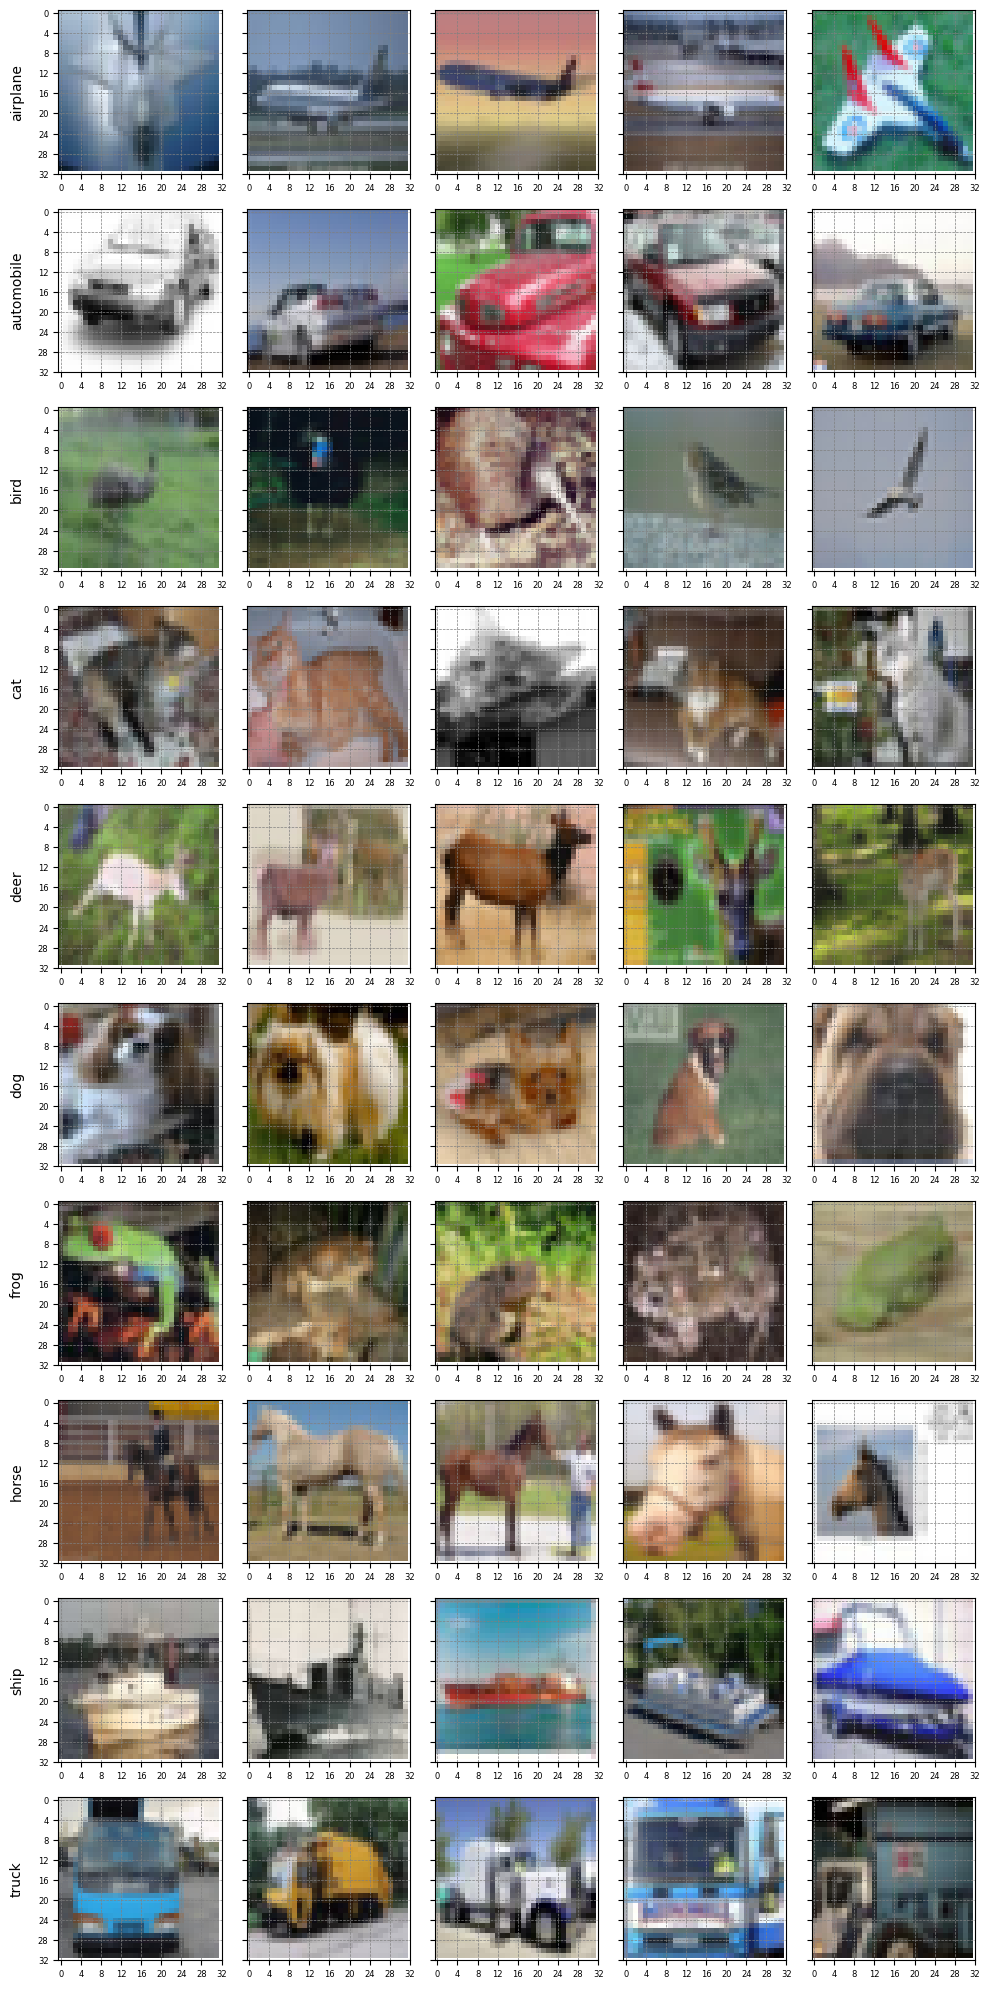

In [6]:
from tsilva_notebook_utils.lightning import render_samples_per_class
with dm.no_augmentations(): render_samples_per_class(dm, n_samples=5, split='train')

Create the model:

In [7]:
import torch
from torch import nn
import pytorch_lightning as pl

class LitModel(pl.LightningModule):
    def __init__(self, lr=None, n_classes=None):
        super().__init__()

        self.save_hyperparameters()

        assert n_classes is not None, "n_classes must be provided"
        
        # Load model from torch hub
        self.model = torch.hub.load("pytorch/vision", CONFIG["model_id"], weights="DEFAULT")

        # Swap out classification head (eg: pretrained weights may have different number of classes)
        self.replace_classifier(n_classes) # TODO: remove last layer instead?

        self.criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG['label_smoothing'])
    
    def get_last_linear(self):
        _, last_module = list(self.model.named_children())[-1]
        if isinstance(last_module, nn.Sequential): return last_module[-1]
        else: return last_module

    def replace_classifier(self, n_classes):
        last_name, last_module = list(self.model.named_children())[-1]
        if isinstance(last_module, nn.Sequential):  last_module[-1] = nn.Linear(last_module[-1].in_features, n_classes, bias=last_module[-1].bias is not None)
        else: setattr(self.model, last_name, nn.Linear(last_module.in_features, n_classes, bias=last_module.bias is not None))

    def freeze_backbone(self):
        head = self.get_last_linear()
        for param in self.model.parameters(): param.requires_grad = False
        for param in head.parameters(): param.requires_grad = True

    def unfreeze_backbone(self):
        head = self.get_last_linear()
        for param in self.model.parameters(): param.requires_grad = True
        for param in head.parameters(): param.requires_grad = True

    def forward(self, x):
        x = self.model(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train/loss", loss, prog_bar=True)
        self.log("train/acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=1)
        acc = (preds == y).float().mean()
        self.log("val/loss", loss, prog_bar=True, sync_dist=True)
        self.log("val/acc", acc, prog_bar=True, sync_dist=True)
        return {}

    def on_validation_epoch_end(self):
        pass

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("test/loss", loss)
        self.log("test/acc", acc)

    def configure_optimizers(self):
        import bitsandbytes as bnb

        optimizer = bnb.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=CONFIG['weight_decay'],
            optim_bits=8
            # Optionally: set optim_bits=8 for 8-bit optimizer
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val/loss",
                "interval": "epoch",
                "frequency": 1
            }
        }

model = LitModel(
    lr=CONFIG['learning_rate'],
    n_classes=len(dm.class_names)
)
model

Using cache found in /home/tsilva/.cache/torch/hub/pytorch_vision_main


LitModel(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): Conv2dNor

Find optimal batch size:

In [8]:
#from pytorch_lightning.tuner import Tuner
#trainer = pl.Trainer()
#tuner = Tuner(trainer)
#tuner.scale_batch_size(model, datamodule=dm, mode="power")

First try to overfit a batch to make sure the training pipeline works:

In [9]:
from tsilva_notebook_utils.lightning import overfit_batches

overfit_batches(
    LitModel(
        lr=CONFIG['learning_rate'],
        n_classes=len(dm.class_names)
    ),
    create_data_module(CONFIG, batch_size=32, train_shuffle=False)
)

Using cache found in /home/tsilva/.cache/torch/hub/pytorch_vision_main


Files already downloaded and verified
Files already downloaded and verified


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/tsilva/miniconda3/envs/aiml-notebooks/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
`Trainer(overfit_batches=1)` was configured so 1 batch will be used.


Files already downloaded and verified
Files already downloaded and verified


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | model     | MobileNetV3      | 1.5 M  | train
1 | criterion | CrossEntropyLoss | 0      | train
-------------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
6.112     Total estimated model params size (MB)
210       Modules in train mode
0         Modules in eval mode


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Stopping training as train/acc reached 1.0


Run the training loop:

In [10]:
import pytorch_lightning as pl
from tsilva_notebook_utils.lightning import EpochTimeLogger, BackboneWarmupCallback
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.callbacks import LearningRateMonitor
from pytorch_lightning.callbacks import StochasticWeightAveraging
from pytorch_lightning.profilers import SimpleProfiler

profiler = SimpleProfiler(dirpath=".", filename="profiler_output.txt")

num_gpus = torch.cuda.device_count()
trainer = pl.Trainer(
    devices=num_gpus,
    accelerator="auto", # TODO: is this default?
    strategy="auto", # TODO: is this default?
    benchmark=True,
    max_epochs=CONFIG['n_epochs'],
    log_every_n_steps=5,
    logger=WandbLogger(project=os.environ["NOTEBOOK_ID"], config=CONFIG),
    precision=CONFIG['precision'],
    #profiler="simple",
    #enable_progress_bar=True,
    #enable_model_summary=True,
    # TODO: add callback factory to tsilva_notebook_utils
    enable_checkpointing=False,
    # TODO: encapsulate this
    callbacks=[x for x in [
        EpochTimeLogger(), 
        LearningRateMonitor(logging_interval="epoch"),
        EarlyStopping(
            monitor="val/loss",
            patience=CONFIG['early_stopping_patience'],
            min_delta=CONFIG['early_stopping_min_delta'],
            mode="min",
            verbose=True,
            strict=True
        ) if CONFIG['early_stopping_patience'] > 0 else None,
        StochasticWeightAveraging(swa_lrs=CONFIG['swa_lrs']) if CONFIG['swa_lrs'] > 0 else None,
        BackboneWarmupCallback(CONFIG['backbone_warmup_percentage']) if CONFIG['backbone_warmup_percentage'] > 0 else None
    ] if x is not None]
)
model = LitModel(
    lr=CONFIG['learning_rate'],
    n_classes=len(dm.class_names)
)
trainer.fit(model, datamodule=dm)


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Using cache found in /home/tsilva/.cache/torch/hub/pytorch_vision_main


Files already downloaded and verified
Files already downloaded and verified


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | model     | MobileNetV3      | 1.5 M  | train
1 | criterion | CrossEntropyLoss | 0      | train
-------------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
6.112     Total estimated model params size (MB)
210       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val/loss did not improve in the last 7 records. Best score: 0.249. Signaling Trainer to stop.


Calculate the post-training test set accuracy:

In [11]:
single_gpu_trainer = pl.Trainer(
    devices=1,
    accelerator="auto"
)
single_gpu_trainer.test(model, datamodule=dm)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Files already downloaded and verified
Files already downloaded and verified


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.9506999850273132     │
│         test/loss         │    0.2745988667011261     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.2745988667011261, 'test/acc': 0.9506999850273132}]